In [54]:
using Pkg
Pkg.activate(@__DIR__)

using HDF5
using CSV
using DataFrames
using Korg

# Paths for the TiO ExoMol dataset and legacy Korg linelist
transition_file = "/home/way/KORG_grid/transitions/1H2-16O__POKAZATEL__03300-03400.trans"
states_file = "/home/way/KORG_grid/linelists/exomol/1H2-16O__POKAZATEL_v1.states"
broad_file_1 = "/home/way/Korg_ExoMol/1H2-16O__H2.broad"
broad_file_2 = "/home/way/Korg_ExoMol/1H2-16O__He.broad"
legacy_linelist = "/home/way/KORG_grid/sergeys_linelist.h5"

# Wavelength bounds for ExoMol loading (Å)
lower_wavelength = 30000.0
upper_wavelength = 30010.0

# Test temperature and pressures for absorption
temps = [2000.0, 3000.0]
n_e = [1e12, 1e13]
ξ = 2e5  # 2 km/s in cm/s

# Build a minimal density table for the test
n_densities = Dict(
    Korg.species"H_I" => [1e17, 1e16],
    Korg.species"He_I" => [1e16, 1e15],
    Korg.species"H2" => [1e16, 1e15],
    Korg.species"H2O" => [1e10, 1e10],
)

partition_fns = Dict(
    Korg.species"H2O" => Korg.default_partition_funcs[Korg.species"H2O"]
)

  Activating project at `~/Korg_ExoMol/Korg.jl`


Dict{Korg.Species, Korg.CubicSplines.CubicSpline{Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Float64}} with 1 entry:
  H2O => CubicSpline{Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{…

In [2]:
# legacy_lines = Korg.read_korg_linelist(legacy_linelist)
# println("Legacy linelist lines: ", length(legacy_lines))
# println("Sample legacy lines:")
# legacy_lines[1:min(end, 5)] |> display

# # Inspect broadening parameters for the first few lines
# legacy_samples = legacy_lines[1:min(end, 20)]
# legacy_broadening = DataFrame(
#     wl = [l.wl * 1e8 for l in legacy_samples],
#     log_gf = [l.log_gf for l in legacy_samples],
#     gamma_rad = [l.gamma_rad for l in legacy_samples],
#     gamma_stark = [l.gamma_stark for l in legacy_samples],
#     vdW = [l.vdW for l in legacy_samples],
#     gamma_mol_lorentz = [l.gamma_mol_lorentz for l in legacy_samples],
#     n_exp = [l.n_exp for l in legacy_samples],
# )
# legacy_broadening |> display

In [3]:
h2o_lines = Korg.load_ExoMol_linelist(Korg.species"H2O", states_file, transition_file,
                                        lower_wavelength, upper_wavelength;
                                        verbose=true,
                                        line_strength_cutoff=-15,
                                        T_line_strength=3500.0,
                                        path_flag=1,
                                        broad_files = (broad_file_1, broad_file_2),
                                        )
println("H2O ExoMol lines: ", length(h2o_lines))
println("Sample H2O lines:")
h2o_lines[1:min(end, 5)] |> display

# Inspect broadening parameters for TiO lines
sample_h2o = h2o_lines[1:min(end, 20)]
h2o_broadening = DataFrame(
    wl = [l.wl * 1e8 for l in sample_h2o],
    log_gf = [l.log_gf for l in sample_h2o],
    E_lower = [l.E_lower for l in sample_h2o],
    gamma_rad = [l.gamma_rad for l in sample_h2o],
    gamma_mol_lorentz = [l.gamma_mol_lorentz for l in sample_h2o],
    n_exp = [l.n_exp for l in sample_h2o],
)
h2o_broadening |> display

Loading ExoMol linelist from /home/way/KORG_grid/linelists/exomol/1H2-16O__POKAZATEL_v1.states and /home/way/KORG_grid/transitions/1H2-16O__POKAZATEL__06500-06600.trans. This functionality is experimental. Please report any issues.
Assuming the most abundant isotope for all atoms. Use the isotopes keyword argument to specify otherwise.
Removed 32881621 lines with strength below -15 at T = 3500.0 K out of 33880586 total lines (97%).
H2O ExoMol lines: 998965
Sample H2O lines:


5-element Vector{Korg.Line}:
 H2O 15152.00086 Å (log gf = -7.02, χ = 2.74 eV)
 H2O 15152.001147 Å (log gf = -7.56, χ = 1.95 eV)
 H2O 15152.001216 Å (log gf = -7.29, χ = 2.21 eV)
 H2O 15152.001391 Å (log gf = -6.48, χ = 2.91 eV)
 H2O 15152.001613 Å (log gf = -6.17, χ = 2.49 eV)

Row,wl,log_gf,E_lower,gamma_rad,gamma_mol_lorentz,n_exp
,Float64,Float64,Float64,Float64,Tuple…,Tuple…
1,15152.0,-7.02305,2.73864,2.75522,"(0.0248, 0.0055)","(0.136, 0.08)"
2,15152.0,-7.56267,1.94893,0.79531,"(0.033, 0.0086)","(0.239, 0.154)"
3,15152.0,-7.29164,2.21007,1.48443,"(0.0635, 0.0197)","(0.458, 0.252)"
4,15152.0,-6.47583,2.91447,9.71344,"(0.0344, 0.0091)","(0.248, 0.163)"
5,15152.0,-6.17303,2.49019,19.5064,"(0.0255, 0.0058)","(0.15, 0.09)"
6,15152.0,-7.15607,2.27937,2.02829,"(0.0225, 0.0047)","(0.081, 0.045)"
7,15152.0,-6.3257,3.32943,13.7246,"(0.0231, 0.0049)","(0.1, 0.055)"
8,15152.0,-7.10098,1.40786,2.30264,"(0.0558, 0.0169)","(0.4, 0.246)"
9,15152.0,-7.34686,1.88145,1.3072,"(0.0296, 0.0074)","(0.204, 0.13)"


In [4]:
sum([ismissing(line.gamma_mol_lorentz) for line in h2o_lines])/length(h2o_lines)

0.00020721446697331738

In [5]:
h2o_lines_legacy = Korg.load_ExoMol_linelist(Korg.species"H2O", states_file, transition_file,
                                        lower_wavelength, upper_wavelength;
                                        verbose=true,
                                        line_strength_cutoff=-15,
                                        T_line_strength=3500.0,
                                        path_flag=0,
                                        )
println("H2O ExoMol lines: ", length(h2o_lines_legacy))
println("Sample H2O lines:")
h2o_lines_legacy[1:min(end, 5)] |> display

# Inspect broadening parameters for TiO lines
sample_h2o_legacy = h2o_lines_legacy[1:min(end, 20)]
h2o_broadening_legacy = DataFrame(
    wl = [l.wl * 1e8 for l in sample_h2o_legacy],
    log_gf = [l.log_gf for l in sample_h2o_legacy],
    E_lower = [l.E_lower for l in sample_h2o_legacy],
    gamma_rad = [l.gamma_rad for l in sample_h2o_legacy],
    gamma_mol_lorentz = [l.gamma_mol_lorentz for l in sample_h2o_legacy],
    n_exp = [l.n_exp for l in sample_h2o_legacy],
)
h2o_broadening_legacy |> display

Loading ExoMol linelist from /home/way/KORG_grid/linelists/exomol/1H2-16O__POKAZATEL_v1.states and /home/way/KORG_grid/transitions/1H2-16O__POKAZATEL__06500-06600.trans. This functionality is experimental. Please report any issues.
Using default broadening (only radiative) for this species
Assuming the most abundant isotope for all atoms. Use the isotopes keyword argument to specify otherwise.


InterruptException: Error trying to display an error.

In [6]:
using PythonPlot

wls, flux, continuum = synth(
    Teff=3500, # effective temperature of 5000 Kelvin
    logg=5.0, # surface gravity of 10^(4.32) cm/s²
    M_H=0.5,  # metallicity, [M/H]. Overridden for individual elements by alpha_H and individual abundances
    #C=0.0,    # The Carbon abundance, [C/H].  Works for anything from He to U.
    linelist=h2o_lines,
    wavelengths=(lower_wavelength, upper_wavelength),
    R=5_000,
)

InitError: InitError: InterruptException:
during initialization of module micromamba_jll

In [7]:
wls_legacy, flux_legacy, continuum_legacy = synth(
    Teff=3500, # effective temperature of 5000 Kelvin
    logg=5.0, # surface gravity of 10^(4.32) cm/s²
    M_H=0.5,  # metallicity, [M/H]. Overridden for individual elements by alpha_H and individual abundances
    #C=0.0,    # The Carbon abundance, [C/H].  Works for anything from He to U.
    linelist=h2o_lines_legacy,
    wavelengths=(lower_wavelength, upper_wavelength),
    R=5_000
)

UndefVarError: UndefVarError: `h2o_lines_legacy` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [8]:
figure(figsize=(20, 8))
subplot(211)
plot(wls, flux, color="b", label="Pressure broadened H2O")
plot(wls_legacy, flux_legacy, color="g", label="Old Korg (only radiative)")
legend()
#ylim(0,1.2)
xlabel(L"$\lambda$ [Å]")
ylabel("continuum-normalized flux")

subplot(212)
plot(wls, flux./flux_legacy, color="k")
xlabel(L"$\lambda$ [Å]")
ylabel("pressure broadened / only radiative")

display(gcf())

UndefVarError: UndefVarError: `figure` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [9]:
log10_teffs = [log10(Teff) for Teff in Korg._sdss_marcs_atmospheres[1][1]][1:5]
el_ = @elapsed H2O_MCS = Korg.MolecularCrossSection(h2o_lines, (lower_wavelength, upper_wavelength); vmic_vals=[0.31622777, 5.], log_temp_vals=log10_teffs)
println(el_)

Korg.save_molecular_cross_section("../foobar_H2O.h5", H2O_MCS)

InterruptException: InterruptException:

In [ ]:
A_X = format_A_X(0.5)
atm = Korg.interpolate_marcs(3500, 5.0, A_X)

wls_, flux_, continuum_ = synthesize(
    atm,
    h2o_lines_legacy[1:5],
    A_X,
    (lower_wavelength, upper_wavelength),
    molecular_cross_sections= [H2O_MCS]
    #R=5_000,
    #synthesize_kwargs = ()
)

In [ ]:
H2O_MCS.itp

In [ ]:
figure()
plot(H2O_MCS.itp[:,:,3])
display(gcf())

In [ ]:
wls, itp, species

## Effect of `line_strength_cutoff` on synthesized flux

Test how varying the lower limit of `line_strength_cutoff` changes the synthesized H₂O spectrum. A less-negative cutoff (e.g. -10) keeps only the strongest lines; a more-negative cutoff (e.g. -20) keeps progressively weaker lines. We use the most-negative cutoff as the reference spectrum and plot the fractional deviation for each looser cutoff.

In [62]:
# Cutoffs to test: from strictest (fewest lines) to loosest (reference, most lines)
cutoffs = [-15, -16, -17, -18, -19, -20, -30, -40]
reference_cutoff = minimum(cutoffs)  # most permissive = most lines
T_ls = 3500.0  # temperature used for line strength evaluation

# Replicate the filtering criterion from Korg.approximate_line_strength:
#   log_gf + log10(wl) - log10(ℯ) * E_lower / (kboltz_eV * T)
line_strength(line, T) = line.log_gf + log10(line.wl) - log10(ℯ) * line.E_lower / (Korg.kboltz_eV * T)

println("Loading full linelist once at cutoff = $reference_cutoff ...")
all_lines = Korg.load_ExoMol_linelist(
    Korg.species"H2O", states_file, transition_file,
    lower_wavelength, upper_wavelength;
    verbose=true,
    line_strength_cutoff=reference_cutoff,
    T_line_strength=T_ls,
    path_flag=1,
    broad_files=(broad_file_1, broad_file_2),
)
println("Total lines loaded: $(length(all_lines))\n")

# Pre-compute line strengths once for fast in-memory filtering
all_strengths = [line_strength(l, T_ls) for l in all_lines]

cutoff_results = Dict{Int, Tuple}()

for cutoff in cutoffs
    filtered = all_lines[all_strengths .> cutoff]
    println("cutoff = $cutoff  ->  $(length(filtered)) lines retained")

    wls_c, flux_c, _ = synth(
        Teff=3500,
        logg=5.0,
        M_H=0.5,
        linelist=filtered,
        wavelengths=(lower_wavelength, upper_wavelength),
        R=5_000,
    )
    cutoff_results[cutoff] = (wls_c, flux_c)
end
println("\nAll done.")

Loading full linelist once at cutoff = -40 ...
Loading ExoMol linelist from /home/way/KORG_grid/linelists/exomol/1H2-16O__POKAZATEL_v1.states and /home/way/KORG_grid/transitions/1H2-16O__POKAZATEL__03300-03400.trans. This functionality is experimental. Please report any issues.
Assuming the most abundant isotope for all atoms. Use the isotopes keyword argument to specify otherwise.
Removed 46069264 lines with strength below -40 at T = 3500.0 K out of 46586524 total lines (99%).
Total lines loaded: 517260

cutoff = -15  ->  27220 lines retained
cutoff = -16  ->  94451 lines retained
cutoff = -17  ->  247423 lines retained
cutoff = -18  ->  397952 lines retained
cutoff = -19  ->  472162 lines retained
cutoff = -20  ->  500844 lines retained
cutoff = -30  ->  517260 lines retained
cutoff = -40  ->  517260 lines retained

All done.


In [63]:
strength_sort = reverse(sortperm(all_strengths, rev=true));

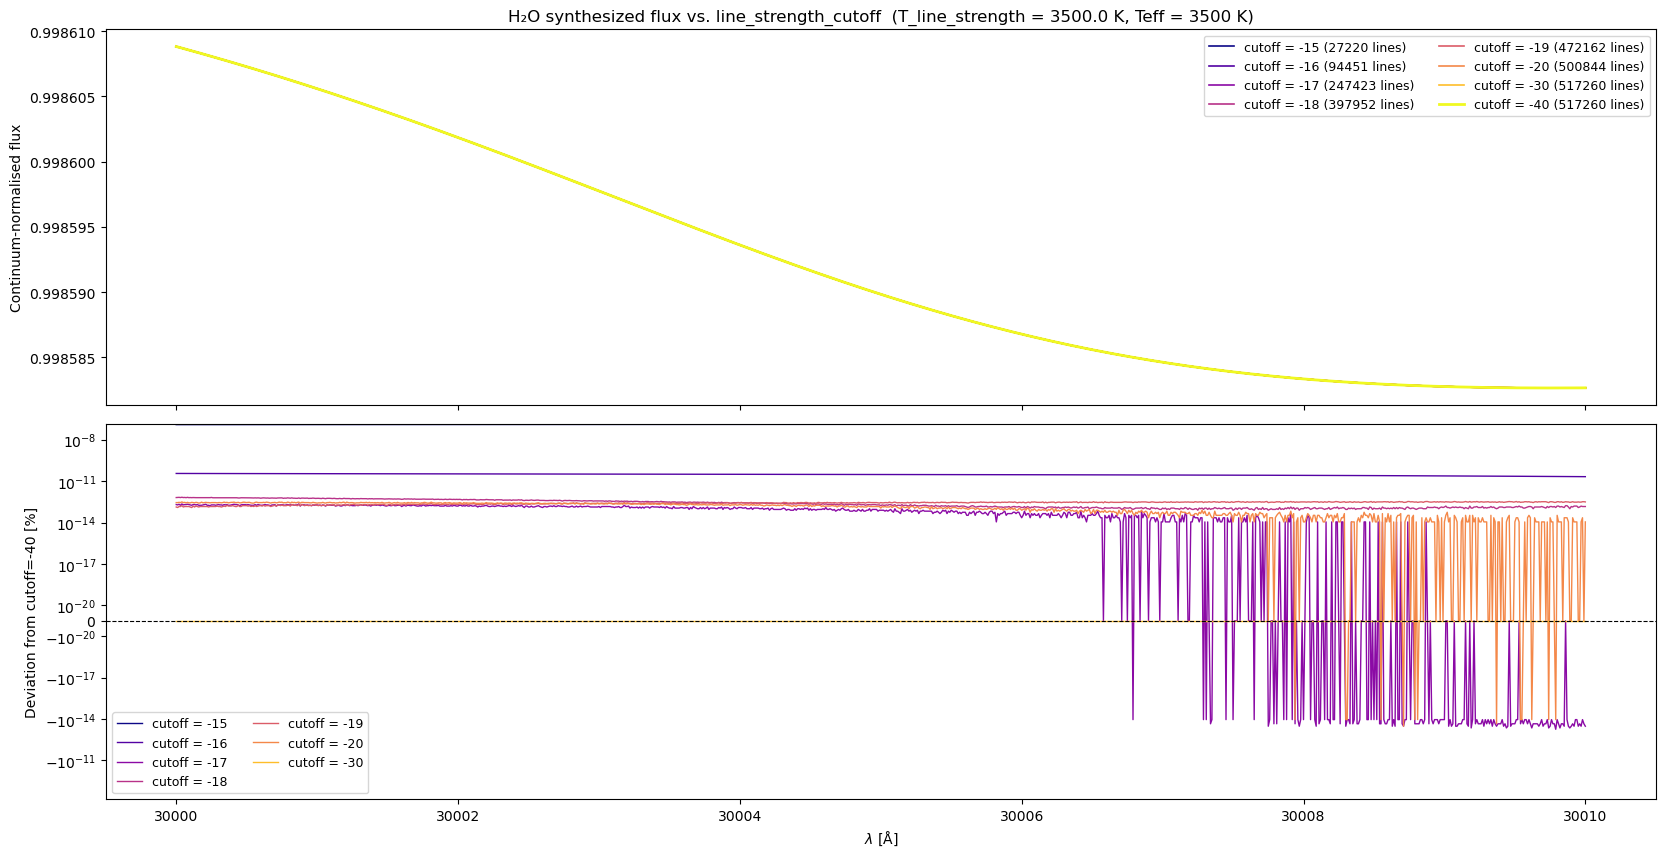

In [64]:
using PythonPlot

wls_ref, flux_ref = cutoff_results[reference_cutoff]

cmap = get_cmap("plasma")
colors = [cmap(i / (length(cutoffs) - 1)) for i in 0:length(cutoffs)-1]

fig, axes = subplots(2, 1, figsize=(20, 10), sharex=true)
fig.subplots_adjust(hspace=0.05)
ax1, ax2 = axes[0], axes[1]

for (i, cutoff) in enumerate(cutoffs[1:end])
    wls_c, flux_c = cutoff_results[cutoff]
    lw = cutoff == reference_cutoff ? 2.0 : 1.2
    n_lines = sum(all_strengths .> cutoff)
    ax1.plot(wls_c, flux_c, color=colors[i], linewidth=lw, label="cutoff = $cutoff ($n_lines lines)")
end
ax1.set_ylabel("Continuum-normalised flux")
ax1.legend(fontsize=9, ncol=2)
ax1.set_title("H₂O synthesized flux vs. line_strength_cutoff  (T_line_strength = $(T_ls) K, Teff = 3500 K)")
#ax1.set_ylim(0.95, 1.05)
#ax1.set_yscale("symlog", linthresh=1e-14)

for (i, cutoff) in enumerate(cutoffs[1:end-1])  # skip reference
    wls_c, flux_c = cutoff_results[cutoff]
    residual = (flux_c .- flux_ref) ./ flux_ref
    ax2.plot(wls_c, residual .* 100, color=colors[i], linewidth=1.0, label="cutoff = $cutoff")
end
ax2.axhline(0, color="k", linewidth=0.8, linestyle="--")
ax2.set_xlabel(L"$\lambda$ [Å]")
ax2.set_ylabel("Deviation from cutoff=$reference_cutoff [%]")
ax2.legend(fontsize=9, ncol=2)
ax2.set_yscale("symlog", linthresh=1e-20)  # log scale for deviations, with linear region around 0
display(gcf())

In [65]:
# Convergence summary: max absolute and RMS deviation vs. reference cutoff
using Statistics

println("Convergence summary (reference = cutoff $reference_cutoff)")
println(rpad("cutoff", 10), rpad("n_wl_pts", 12), rpad("max |Δflux| [%]", 18), "RMS Δflux [%]")
println("-"^58)
for cutoff in cutoffs[1:end-1]
    wls_c, flux_c = cutoff_results[cutoff]
    residual_pct = (flux_c .- flux_ref) ./ flux_ref .* 100
    println(
        rpad(cutoff, 10),
        rpad(length(wls_c), 12),
        rpad(round(maximum(abs.(residual_pct)), digits=4), 18),
        round(sqrt(mean(residual_pct .^ 2)), digits=4),
    )
end

Convergence summary (reference = cutoff -40)
cutoff    n_wl_pts    max |Δflux| [%]   RMS Δflux [%]
----------------------------------------------------------
-15       1001        0.0               0.0
-16       1001        0.0               0.0
-17       1001        0.0               0.0
-18       1001        0.0               0.0
-19       1001        0.0               0.0
-20       1001        0.0               0.0
-30       1001        0.0               0.0


## Iterative convergence: strongest lines first

Sort all lines by line strength and add them in batches of 10⁴ (strongest first).
After each batch, recompute the spectrum using the **cumulative** precomputed cross-section and compare with the previous spectrum.
Stop when the maximum absolute change in continuum-normalised flux drops below 0.01.

In [66]:
using Interpolations: interpolate!, Gridded, Linear, extrapolate

# Sort lines by decreasing strength (strongest first)
strength_sorted_idx = sortperm(all_strengths, rev=true)
sorted_lines_conv   = all_lines[strength_sorted_idx]
sorted_strengths_conv = all_strengths[strength_sorted_idx]
println("Lines sorted: strongest = $(round(sorted_strengths_conv[1], digits=2)), ",
        "weakest = $(round(sorted_strengths_conv[end], digits=2))")

# Helper: add two MolecularCrossSection objects (must share same grid)
# Cross-sections are additive, so we sum the raw coefficient arrays.
function add_mcs(mcs1::Korg.MolecularCrossSection, mcs2::Korg.MolecularCrossSection)
    @assert mcs1.species == mcs2.species "Species must match"
    knots    = mcs1.itp.itp.knots
    combined = copy(mcs1.itp.itp.coefs) .+ mcs2.itp.itp.coefs
    itp = extrapolate(
        interpolate!(knots, combined,
                     (Gridded(Linear()), Gridded(Linear()),
                      Gridded(Linear()), Gridded(Linear()))),
        0.0,
    )
    Korg.MolecularCrossSection(mcs1.wls, itp, mcs1.species)
end

# Atmosphere for synthesis (fixed for the whole convergence run)
A_X_conv  = format_A_X(0.5)
atm_conv  = Korg.interpolate_marcs(3500, 5.0, A_X_conv)

# MCS grid — compact but wide enough to cover the full atmosphere
mcs_vmic_vals    = [0.0, 1.0, 2.0, 4.0]
mcs_log_temp_vals = collect(3.0:0.1:4.0)   # 1000–10000 K
mcs_log_pd        = collect(12.0:2.0:20.0)  # log perturber density

println("MCS grid: $(length(mcs_vmic_vals)) vmic × ",
        "$(length(mcs_log_temp_vals)) T × ",
        "$(length(mcs_log_pd)) log_pd")

Lines sorted: strongest = -8.39, weakest = -29.1
MCS grid: 4 vmic × 11 T × 5 log_pd


In [67]:
using Printf

batch_size = 10_000
tolerance  = 0.01   # max |Δ continuum-normalised flux|

n_total     = length(sorted_lines_conv)
cumulative_mcs = nothing
prev_flux      = nothing
wls_conv       = nothing
conv_fluxes    = Vector{Float64}[]   # one vector per batch
conv_max_diffs = Float64[]
n_processed    = 0
batch_num      = 0
converged      = false

@printf("Total lines: %d,  batch size: %d,  tolerance: %.3f\n\n",
        n_total, batch_size, tolerance)

while !converged && n_processed < n_total
    batch_num += 1
    n_start = n_processed + 1
    n_end   = min(n_processed + batch_size, n_total)
    batch   = sorted_lines_conv[n_start:n_end]

    @printf("── Batch %d: lines %d–%d  (strength %.2f → %.2f)\n",
            batch_num, n_start, n_end,
            sorted_strengths_conv[n_start], sorted_strengths_conv[n_end])

    # Step 4 / repeat: compute MCS for this batch
    t_mcs = @elapsed begin
        batch_mcs = Korg.MolecularCrossSection(
            batch, (lower_wavelength, upper_wavelength);
            vmic_vals           = mcs_vmic_vals,
            log_temp_vals       = mcs_log_temp_vals,
            log_perturber_density = mcs_log_pd,
        )
    end
    @printf("  MCS:       %.1f s\n", t_mcs)

    # Accumulate: add batch MCS into the running total
    if cumulative_mcs === nothing
        cumulative_mcs = batch_mcs
    else
        cumulative_mcs = add_mcs(cumulative_mcs, batch_mcs)
    end

    # Step 5 / 6: synthesize using cumulative MCS (no H2O in linelist — it's all in the MCS)
    t_synth = @elapsed begin
        result = synthesize(
            atm_conv,
            Korg.Line[],
            A_X_conv,
            (lower_wavelength, upper_wavelength),
            molecular_cross_sections = [cumulative_mcs],
        )
        wls_conv  = result.wavelengths
        flux_curr = result.flux
    end
    @printf("  Synthesis: %.2f s\n", t_synth)

    push!(conv_fluxes, copy(flux_curr))

    # Step 7: compare with previous spectrum
    if prev_flux !== nothing
        max_diff = maximum(abs.(flux_curr .- prev_flux))
        push!(conv_max_diffs, max_diff)
        @printf("  Max|Δflux| = %.5f", max_diff)
        if max_diff < tolerance
            converged = true
            print("  ✓ CONVERGED")
        end
        println()
    else
        println("  (first batch — no comparison yet)")
    end

    prev_flux   = flux_curr
    n_processed = n_end
    println()
end

if converged
    @printf("Converged after %d lines (%d batches).\n", n_processed, batch_num)
else
    @printf("All %d lines processed; final max|Δflux| = %.5f (did not reach %.3f).\n",
            n_total, isempty(conv_max_diffs) ? NaN : conv_max_diffs[end], tolerance)
end

Total lines: 517260,  batch size: 10000,  tolerance: 0.010

── Batch 1: lines 1–10000  (strength -8.39 → -14.23)
  MCS:       5.3 s
  Synthesis: 0.79 s
  (first batch — no comparison yet)

── Batch 2: lines 10001–20000  (strength -14.23 → -14.76)
  MCS:       4.8 s
  Synthesis: 0.75 s
  Max|Δflux| = 0.53477

── Batch 3: lines 20001–30000  (strength -14.76 → -15.07)
  MCS:       4.7 s
  Synthesis: 0.75 s
  Max|Δflux| = 0.22157

── Batch 4: lines 30001–40000  (strength -15.07 → -15.30)
  MCS:       4.7 s
  Synthesis: 1.01 s
  Max|Δflux| = 0.11926

── Batch 5: lines 40001–50000  (strength -15.30 → -15.48)
  MCS:       4.6 s
  Synthesis: 0.82 s
  Max|Δflux| = 0.06038

── Batch 6: lines 50001–60000  (strength -15.48 → -15.62)
  MCS:       4.6 s
  Synthesis: 0.83 s
  Max|Δflux| = 0.06453

── Batch 7: lines 60001–70000  (strength -15.62 → -15.75)
  MCS:       4.5 s
  Synthesis: 0.87 s
  Max|Δflux| = 0.04015

── Batch 8: lines 70001–80000  (strength -15.75 → -15.86)
  MCS:       4.7 s
  Synthe

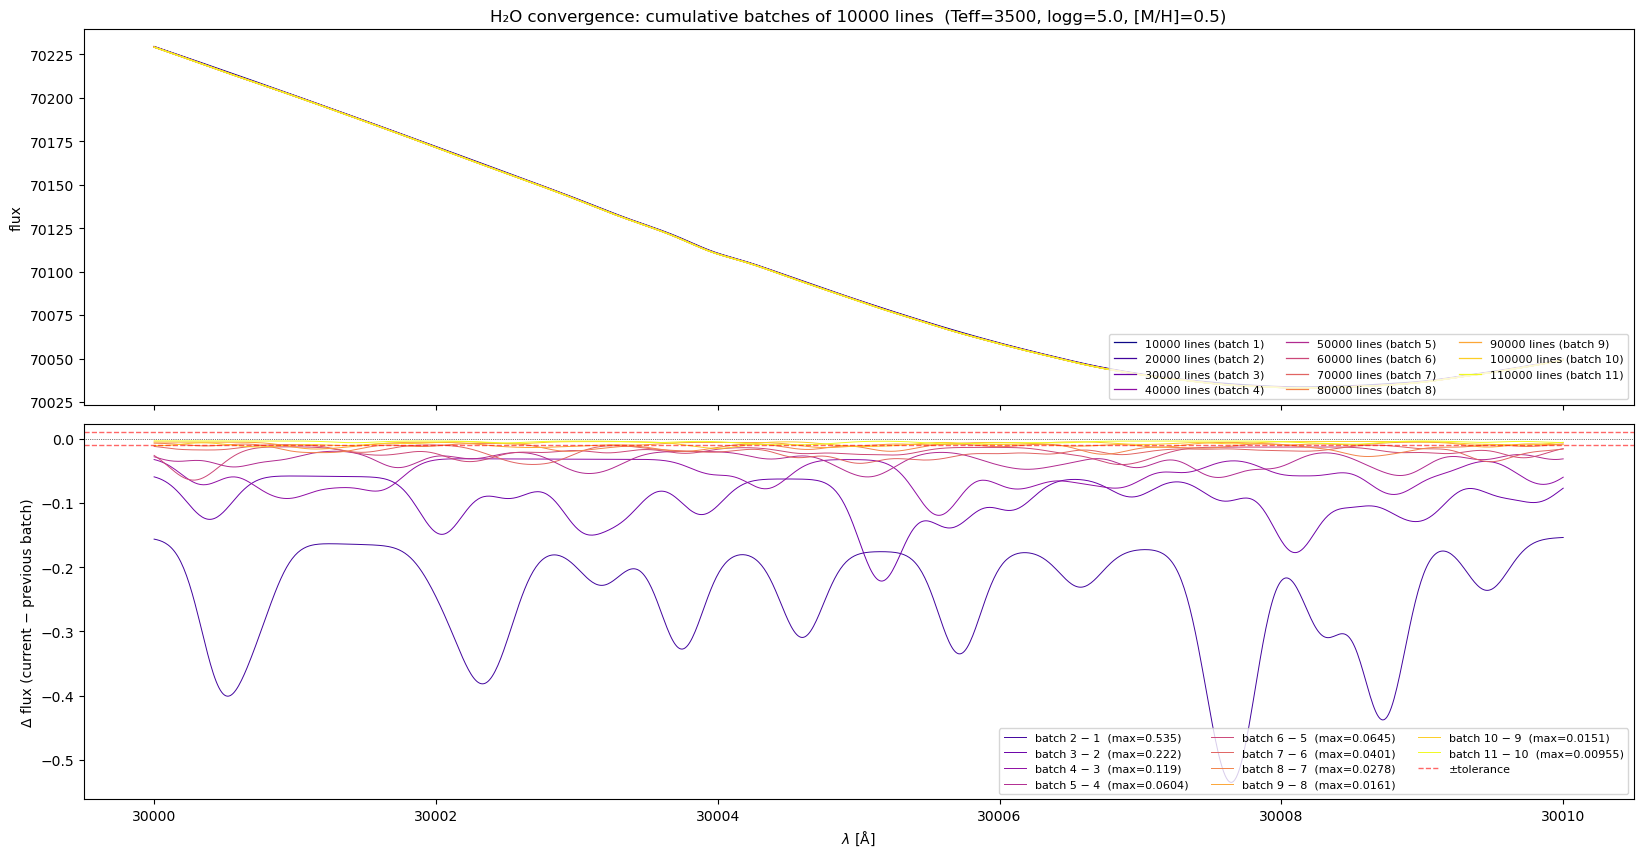


Batch-to-batch max|Δflux|:
  batch 1→2: 0.53477
  batch 2→3: 0.22157
  batch 3→4: 0.11926
  batch 4→5: 0.06038
  batch 5→6: 0.06453
  batch 6→7: 0.04015
  batch 7→8: 0.02778
  batch 8→9: 0.01612
  batch 9→10: 0.01512
  batch 10→11: 0.00955  ✓


In [68]:
using PythonPlot

n_batches = length(conv_fluxes)
cmap_conv = get_cmap("plasma")
colors_conv = [cmap_conv((i - 1) / max(n_batches - 1, 1)) for i in 1:n_batches]

fig, axes = subplots(2, 1, figsize=(20, 10), sharex=true)
fig.subplots_adjust(hspace=0.05)
ax1, ax2 = axes[0], axes[1]

# Top panel: spectrum after each cumulative batch
for (i, f) in enumerate(conv_fluxes)
    n_lines = min(i * batch_size, n_total)
    ax1.plot(wls_conv, f, color=colors_conv[i], linewidth=0.9,
             label="$n_lines lines (batch $i)")
end
ax1.set_ylabel("flux")
ax1.legend(fontsize=8, ncol=3, loc="lower right")
ax1.set_title("H₂O convergence: cumulative batches of $batch_size lines  " *
              "(Teff=3500, logg=5.0, [M/H]=0.5)")

# Bottom panel: batch-to-batch difference
if length(conv_max_diffs) > 0
    for i in 1:length(conv_max_diffs)
        diff = conv_fluxes[i + 1] .- conv_fluxes[i]
        ax2.plot(wls_conv, diff, color=colors_conv[i + 1], linewidth=0.7,
                 label="batch $(i+1) − $i  (max=$(round(conv_max_diffs[i], sigdigits=3)))")
    end
    ax2.axhline( tolerance, color="r", linewidth=1.0, linestyle="--", alpha=0.6, label="±tolerance")
    ax2.axhline(-tolerance, color="r", linewidth=1.0, linestyle="--", alpha=0.6)
    ax2.axhline(0, color="k", linewidth=0.5, linestyle=":")
    ax2.set_ylabel("Δ flux (current − previous batch)")
    ax2.legend(fontsize=8, ncol=3, loc="lower right")
end
ax2.set_xlabel(L"$\lambda$ [Å]")

display(gcf())

# Summary table
println("\nBatch-to-batch max|Δflux|:")
for (i, d) in enumerate(conv_max_diffs)
    @printf("  batch %d→%d: %.5f%s\n", i, i+1, d, d < tolerance ? "  ✓" : "")
end